In [53]:
from scipy.interpolate import CubicSpline
from scipy.optimize import curve_fit
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
%config InlineBackend.figure_format ='retina'
sns.set(style="whitegrid")

In [ ]:
def load_yield_data(file_path):

    sheet_names = pd.ExcelFile(file_path).sheet_names
    try:
        yield_data = pd.read_excel(file_path, sheet_name=sheet_names, index_col=0, parse_dates=True)
    except Exception as e:
        raise RuntimeError(f"Error reading file '{file_path}': {e}")

    return yield_data

In [32]:
file_path = "yc_data_historical.xlsx"  # Update path if necessary
yield_curves = load_yield_data(file_path)

In [5]:
yield_curves.keys()

dict_keys(['USD_Z0', 'EUR_Z0', 'GBP_Z0'])

### Select the desired curve

In [33]:
# yc_usd = yield_curves['USD_Z0']
yc_eur = yield_curves['EUR_Z0']

In [47]:
# yc_df = yc_usd.iloc[:,1:]
yc_df = yc_eur.iloc[:,1:]

In [48]:
yc_df.index = pd.to_datetime(yc_df.index)
# Get the last available data
latest_date = yc_df.index[-1]
latest_yield_curve = yc_df.loc[latest_date]
tenors = latest_yield_curve.index.astype(float)

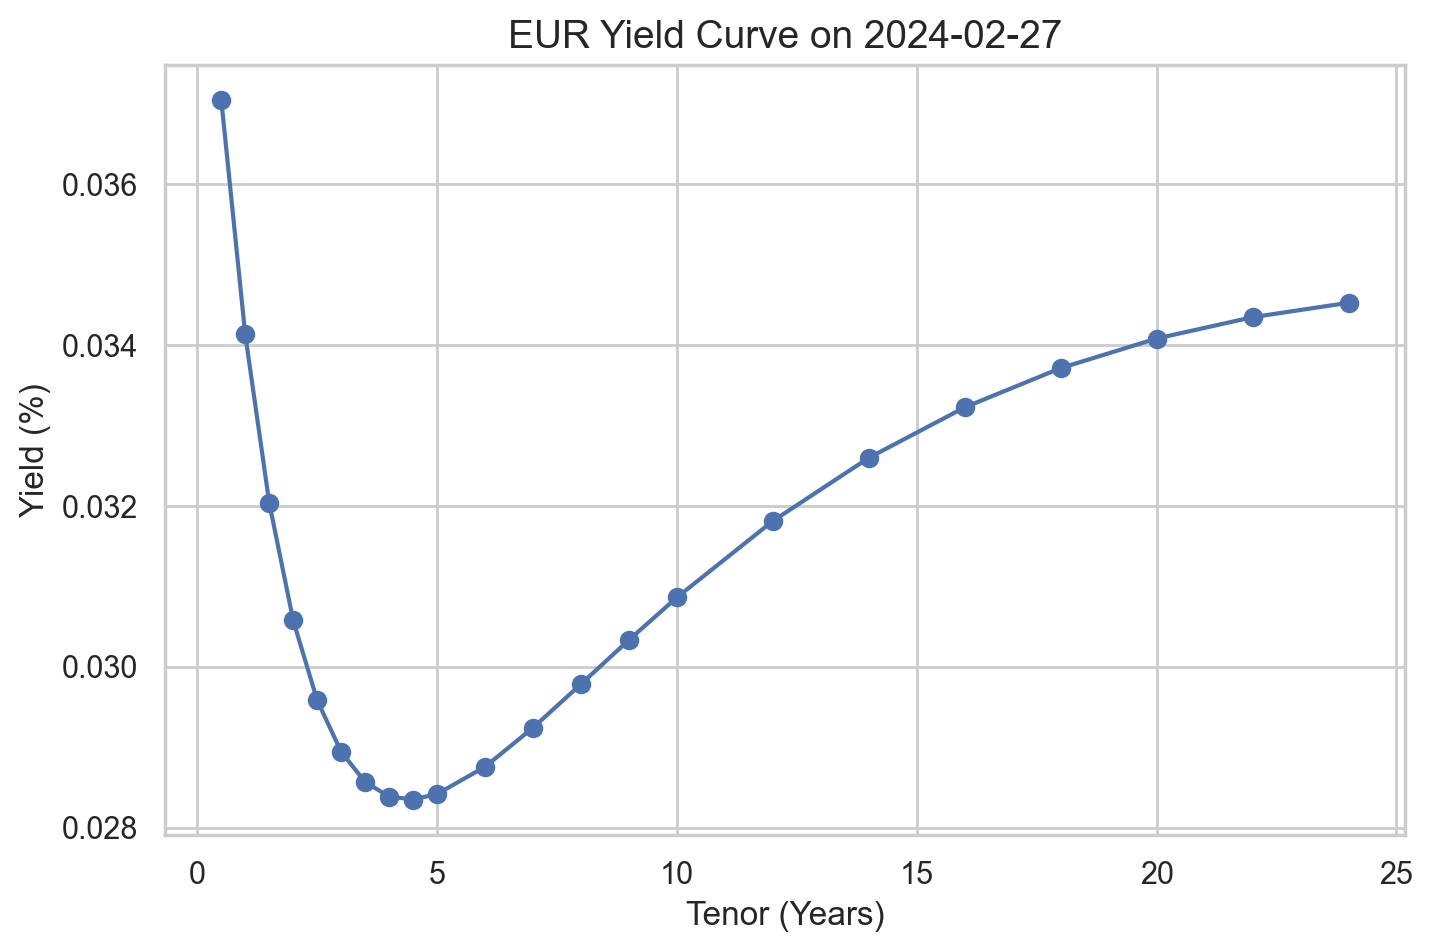

In [49]:
plt.figure(figsize=(8, 5))
plt.plot(tenors, latest_yield_curve, marker='o', linestyle='-')
plt.title(f"EUR Yield Curve on {latest_date.date()}", fontsize=14)
plt.xlabel("Tenor (Years)", fontsize=12)
plt.ylabel("Yield (%)", fontsize=12)
plt.grid(True)
plt.show()

In [50]:
spline = CubicSpline(tenors, latest_yield_curve)
fine_maturities = np.linspace(.5, 24, 100)  
interpolated_yields = spline(fine_maturities)

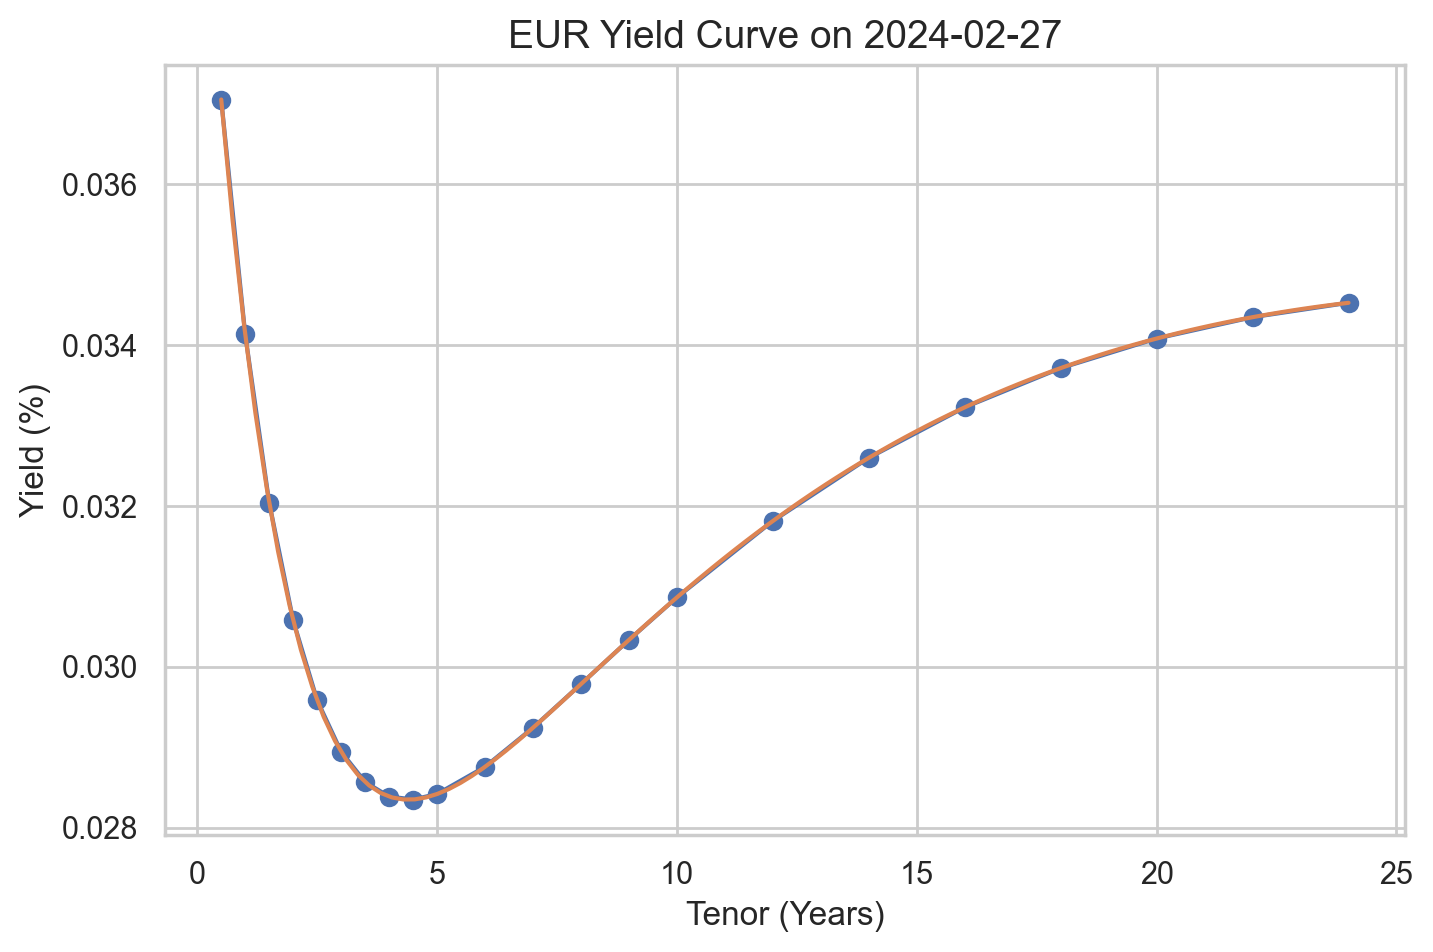

In [52]:
plt.figure(figsize=(8, 5))
plt.plot(tenors, latest_yield_curve, marker='o')
plt.plot(fine_maturities, interpolated_yields, '-', label='Interpolated Curve')
plt.title(f"EUR Yield Curve on {latest_date.date()}", fontsize=14)
plt.xlabel("Tenor (Years)", fontsize=12)
plt.ylabel("Yield (%)", fontsize=12)
plt.grid(True)
plt.show()

## Nelson-Siegel

The Nelson-Siegel formula for the instantaneous forward rate  f(t)  is:


$$ f(t) = \beta_0 + \beta_1 \left( \frac{1 - e^{-t/\tau}}{t/\tau} \right) + \beta_2 \left( \frac{1 - e^{-t/\tau}}{t/\tau} - e^{-t/\tau} \right) $$


Where:
- $\beta_0$  = Long-term level (as  t \to \infty )
- $\beta_1$  = Short-term component
-  $\beta_2$  = Medium-term component (captures hump or dip)
-  $\tau$  = Decay factor controlling curvature
  

### Applications of Nelson-Siegel

- Bond Pricing: Used to interpolate the discount function.
- Monetary Policy: Central banks (e.g., ECB, Fed) use it to monitor the yield curve.
- Risk Management: Used in Value-at-Risk (VaR) and interest rate risk modeling.
- Forecasting Interest Rates: The Nelson-Siegel model is often used in macroeconomic models.

In [54]:
def nelson_siegel(maturity, beta0, beta1, beta2, tau):
    """
    Nelson-Siegel yield curve function.
    
    Parameters:
    - maturity: array of bond maturities
    - beta0: long-term yield component
    - beta1: short-term component
    - beta2: medium-term component (hump or dip)
    - tau: decay factor
    
    Returns:
    - Fitted yield for each maturity
    """
    term = maturity / tau
    return beta0 + beta1 * ((1 - np.exp(-term)) / term) + beta2 * (((1 - np.exp(-term)) / term) - np.exp(-term))

### Example using simulated data

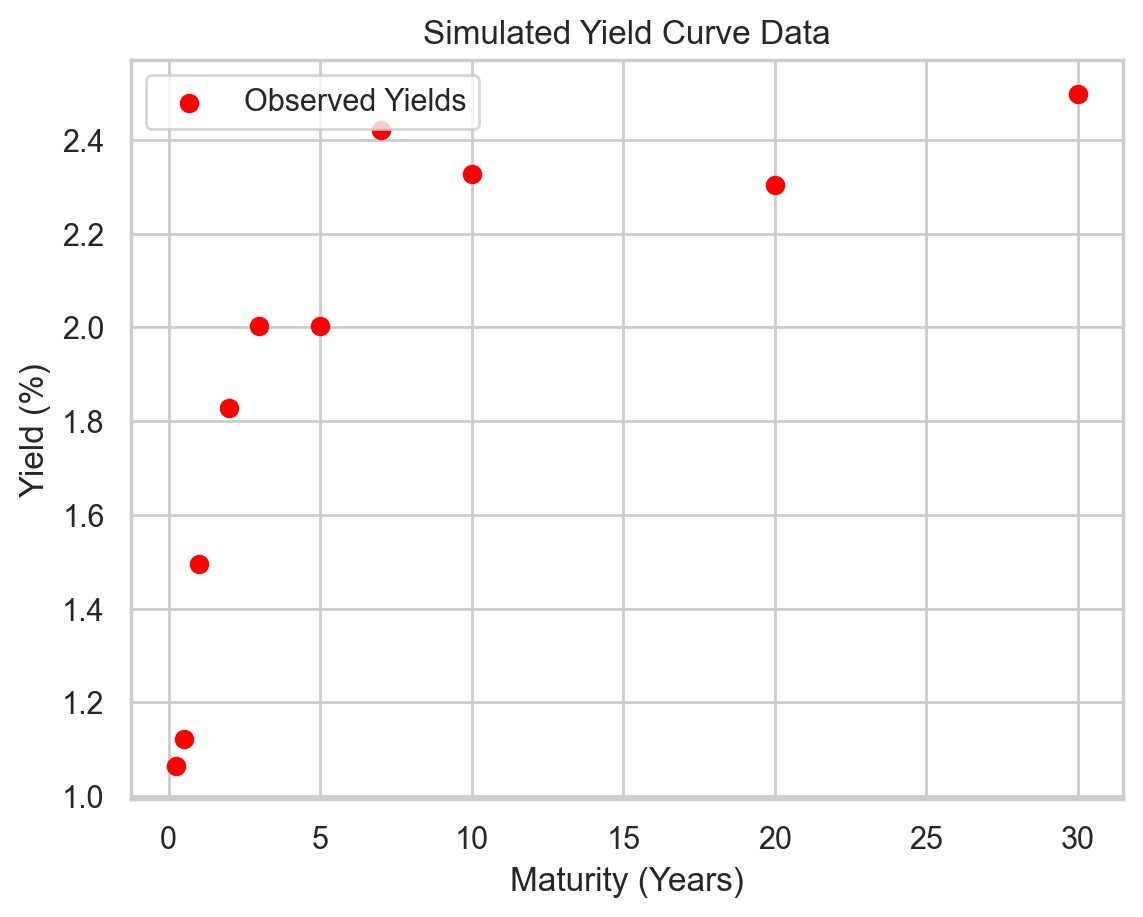

In [55]:
 # Simulated maturities (in years)
maturities = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30])

# Simulated yield curve (assume upward-sloping)
true_params = [2.5, -1.5, 1.2, 3.0]  # (beta0, beta1, beta2, tau)
yields = nelson_siegel(maturities, *true_params) + np.random.normal(0, 0.1, len(maturities))  

plt.scatter(maturities, yields, label="Observed Yields", color="red")
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.title("Simulated Yield Curve Data")
plt.legend()
plt.show()

Fit the Nelson-Siegel Model

In [56]:
# Initial guess for parameters
initial_guess = [2.0, -1.0, 1.0, 2.0]  

# Fit curve using non-linear least squares
optimal_params, _ = curve_fit(nelson_siegel, maturities, yields, p0=initial_guess)

# Extract estimated parameters
beta0_fit, beta1_fit, beta2_fit, tau_fit = optimal_params

print(f"Estimated Parameters:")
print(f"Beta0 (Long-term rate): {beta0_fit:.4f}")
print(f"Beta1 (Short-term component): {beta1_fit:.4f}")
print(f"Beta2 (Hump/Dip component): {beta2_fit:.4f}")
print(f"Tau (Decay factor): {tau_fit:.4f}")

Estimated Parameters:
Beta0 (Long-term rate): 2.4819
Beta1 (Short-term component): -1.6580
Beta2 (Hump/Dip component): 0.0006
Tau (Decay factor): 0.9364


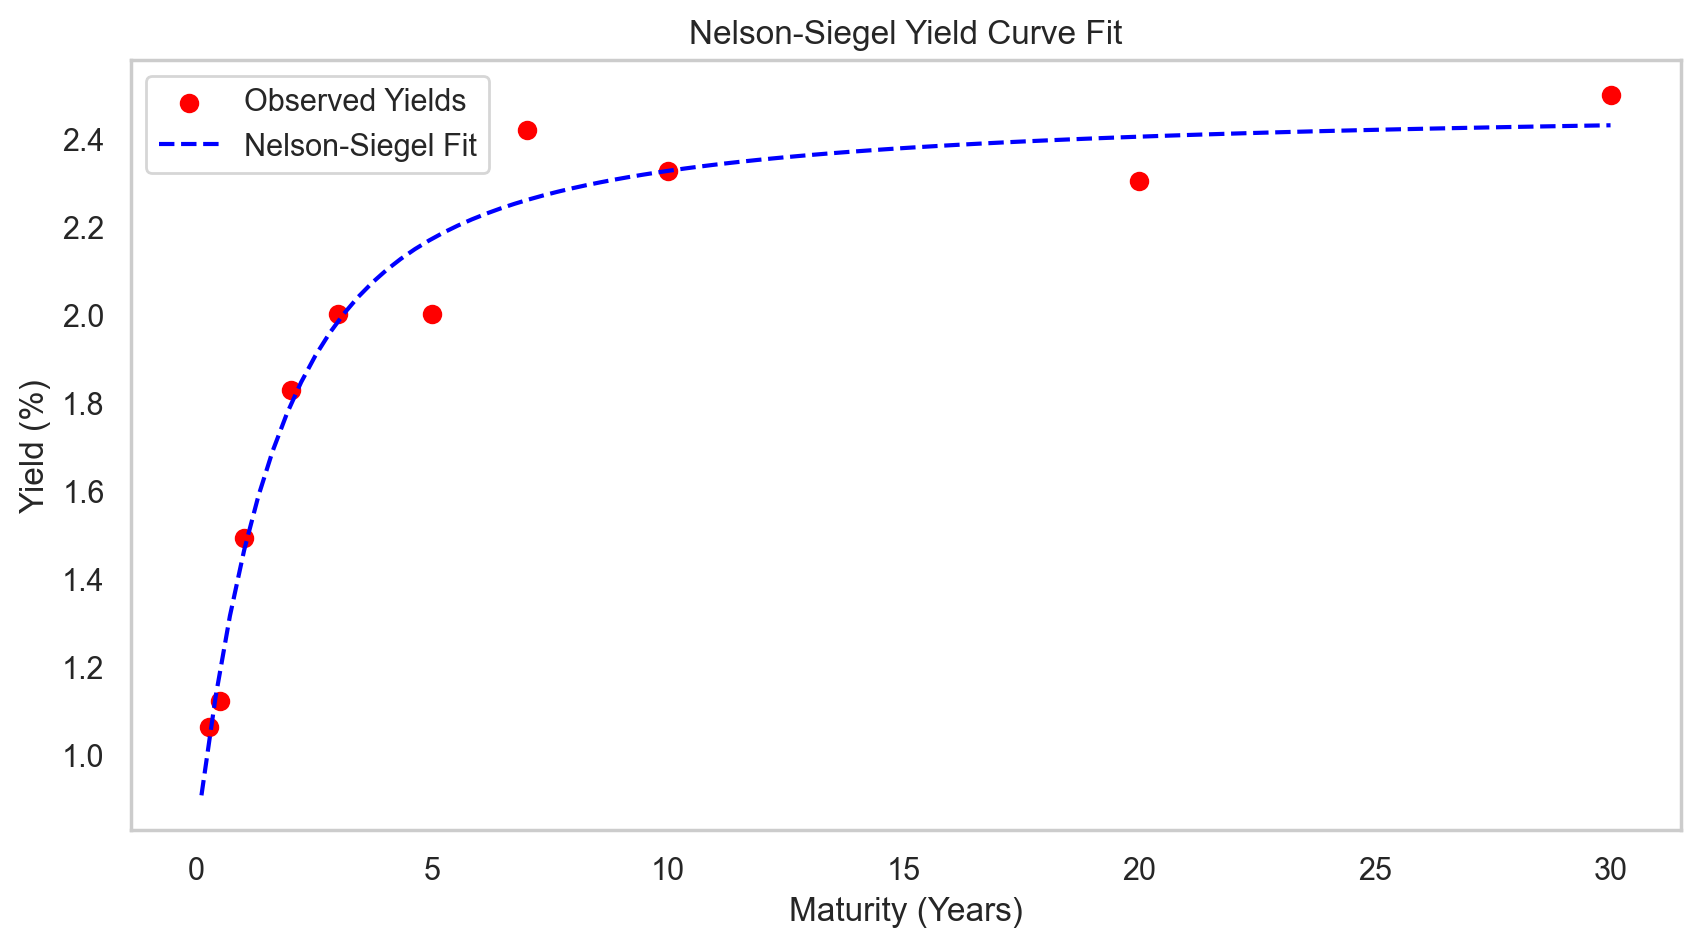

In [57]:
# Generate smooth curve for plotting
maturity_range = np.linspace(0.1, 30, 100)
fitted_yields = nelson_siegel(maturity_range, *optimal_params)

plt.figure(figsize=(10, 5))
plt.scatter(maturities, yields, color="red", label="Observed Yields")
plt.plot(maturity_range, fitted_yields, label="Nelson-Siegel Fit", color="blue", linestyle="--")
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.title("Nelson-Siegel Yield Curve Fit")
plt.legend()
plt.grid()
plt.show()